In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import uproot
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report


Aquí se establecen puntos de corte para eliminar lo que es fondo de lo que es ruido.

In [6]:
# preselection_cut = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) & (L_END_VZ > 5000) '
# preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) & (L_END_VZ > 5000) '
preselection_cut = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '
preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '


second_cuts = '(Cos_xi_LP > 0.9999) & (Cos_xi_LbP > 0.99) & (pim_GHOSTPROB < 0.15) & (p_GHOSTPROB < 0.4) & (mum_GHOSTPROB < 0.4) & (mup_GHOSTPROB < 0.4) & (L_END_VZ > 5000) & (Jpsi_BPVDIRA > 0.999)& (Jpsi_MAXDOCA < 0.10)'
second_cuts_mc = '(Cos_xi_LP > 0.9999) & (Cos_xi_LbP > 0.99) & (pim_GHOSTPROB < 0.15) & (p_GHOSTPROB < 0.4) & (mum_GHOSTPROB < 0.4) & (mup_GHOSTPROB < 0.4) & (L_END_VZ > 5000) & (Jpsi_BPVDIRA > 0.999)& (Jpsi_MAXDOCA < 0.10)'

In [7]:
total_keys = ['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB']

preslection_keys = ['SUMCHI2','Cos_xi_LbP','Cos_xi_LP','xi_LbP', 'xi_LP' ] # ,'xi_LbP', 'xi_LP' 



training_variables = total_keys+preslection_keys

Se cargan los datos de la simulación de Montecarlo, y se añaden nuevas características.

In [8]:
my_tuple_mc_1 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_2 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_3 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")
my_tuple_mc_4 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")

mc_data1 = my_tuple_mc_1.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ'] + ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data2 = my_tuple_mc_2.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data3 = my_tuple_mc_1.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")
mc_data4 = my_tuple_mc_2.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")

mc_data5 = my_tuple_mc_3.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data6 = my_tuple_mc_4.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data7 = my_tuple_mc_3.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")
mc_data8 = my_tuple_mc_4.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")

mc_signal_up = pd.merge(mc_data1, mc_data2, how="outer")
mc_signal_down = pd.merge(mc_data5, mc_data6, how="outer")
mc_signal_merge = pd.merge(mc_signal_up, mc_signal_down, how="outer")

mc_background_up = pd.merge(mc_data3, mc_data4, how="outer")
mc_background_down = pd.merge(mc_data7, mc_data8, how="outer")
mc_background_merge = pd.merge(mc_background_up, mc_background_down, how="outer")

mc_signal_background_merge = pd.merge(mc_signal_merge, mc_background_merge, how="outer")

mc_signal = mc_signal_merge.query(preselection_cut_mc)
mc_bkg= mc_background_merge.query(preselection_cut_mc)

#Creates a new variables like the Cos()...
cos_xi_L = ((mc_signal['p_PX']*mc_signal['L_PX']+mc_signal['p_PY']*mc_signal['L_PY']+mc_signal['p_PZ']*mc_signal['L_PZ'])/(mc_signal['p_P']*mc_signal['L_P']))
cos_xi_Lb = ((mc_signal['p_PX']*mc_signal['Lb_PX']+mc_signal['p_PY']*mc_signal['Lb_PY']+mc_signal['p_PZ']*mc_signal['Lb_PZ'])/(mc_signal['p_P']*mc_signal['Lb_P']))
xi_L = np.arccos(cos_xi_L)
xi_Lb  = np.arccos(cos_xi_Lb)
#Add the new varaibles to signal_data
mc_signal['Cos_xi_LbP'] = cos_xi_L
mc_signal['Cos_xi_LP'] = cos_xi_Lb
mc_signal['xi_LP'] = xi_L
mc_signal['xi_LbP'] = xi_Lb
mc_signal['SUMCHI2'] = mc_signal['L_CHI2'] + mc_signal['Lb_CHI2'] + mc_signal['Jpsi_CHI2']
mc_signal_selected_chi2  = mc_signal[mc_signal.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==mc_signal['SUMCHI2']].drop_duplicates('EVENTNUMBER')
mc_signal_selected  = mc_signal_selected_chi2[mc_signal_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==mc_signal_selected_chi2['p_PID_P']].drop_duplicates()

#Creates a new variables like the Cos()...

cos_xi_L = ((mc_bkg['p_PX']*mc_bkg['L_PX']+mc_bkg['p_PY']*mc_bkg['L_PY']+mc_bkg['p_PZ']*mc_bkg['L_PZ'])/(mc_bkg['p_P']*mc_bkg['L_P']))
cos_xi_Lb = ((mc_bkg['p_PX']*mc_bkg['Lb_PX']+mc_bkg['p_PY']*mc_bkg['Lb_PY']+mc_bkg['p_PZ']*mc_bkg['Lb_PZ'])/(mc_bkg['p_P']*mc_bkg['Lb_P']))
xi_L = np.arccos(cos_xi_L)
xi_Lb  = np.arccos(cos_xi_Lb)
#Add the new varaibles to signal_data

mc_bkg['Cos_xi_LP'] = cos_xi_L
mc_bkg['Cos_xi_LbP'] = cos_xi_Lb
mc_bkg['xi_LP'] = xi_L
mc_bkg['xi_LbP'] = xi_Lb
mc_bkg['SUMCHI2'] = mc_bkg['L_CHI2'] + mc_bkg['Lb_CHI2'] + mc_bkg['Jpsi_CHI2']
mc_bkg_selected_chi2  = mc_bkg[mc_bkg.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==mc_bkg['SUMCHI2']].drop_duplicates('EVENTNUMBER')
mc_bkg_selected  = mc_bkg_selected_chi2[mc_bkg_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==mc_bkg_selected_chi2['p_PID_P']].drop_duplicates()

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_11094/550664457.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['Cos_xi_LbP'] = cos_xi_L
/tmp/javeser/ipykernel_11094/550664457.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['Cos_xi_LP'] = cos_xi_Lb
/tmp/javeser/ipykernel_11094/550664457.py:37: SettingWithCopyWarning: 
A

In [9]:
print(len(mc_data3['Lb_BKGCAT']))
print(len(mc_data3[mc_data3.Lb_BKGCAT == 0]))

44431
3099


Se cargan los datos de los experimentos.

In [10]:
path = "/l/belfern/Datasets/data24_training.pkl"
data24 = pd.read_pickle(path)

#Creates a new variables like the Cos()...

cos_xi_L_data = ((data24['p_PX']*data24['L_PX']+data24['p_PY']*data24['L_PY']+data24['p_PZ']*data24['L_PZ'])/(data24['p_P']*data24['L_P']))
cos_xi_Lb_data = ((data24['p_PX']*data24['Lb_PX']+data24['p_PY']*data24['Lb_PY']+data24['p_PZ']*data24['Lb_PZ'])/(data24['p_P']*data24['Lb_P']))
xi_L_data = np.arccos(cos_xi_L_data)
xi_Lb_data  = np.arccos(cos_xi_Lb_data)

#Add the new varaibles to signal_data
data24['Cos_xi_LP'] = cos_xi_L_data
data24['Cos_xi_LbP'] = cos_xi_Lb_data
data24['xi_LP'] = xi_L_data
data24['xi_LbP'] = xi_Lb_data

data24['SUMCHI2'] = data24['L_CHI2'] + data24['Lb_CHI2'] + data24['Jpsi_CHI2']
data24_selected_chi2  = data24[data24.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==data24['SUMCHI2']].drop_duplicates('EVENTNUMBER')
data24_selected  = data24_selected_chi2[data24_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==data24_selected_chi2['p_PID_P']].drop_duplicates()

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


Se seleccionan las variables de entrenamiento.

In [11]:
mc_signal_columns = training_variables + ['Lb_BKGCAT', 'p_TRUEORIGIN_VZ', 'Lb_MASS']
mc_signal_selected = mc_signal_selected[mc_signal_columns]

mc_bkg_columns = training_variables + ['Lb_BKGCAT', 'p_TRUEORIGIN_VZ', 'Lb_MASS']
mc_bkg_selected = mc_bkg_selected[mc_bkg_columns]

data24_selected_columns = training_variables + ['Lb_MASS']
data24_selected = data24_selected[data24_selected_columns]

In [12]:
training_data = mc_signal_selected.merge(mc_bkg_selected.sample(len(mc_bkg_selected)),how='outer')

In [13]:
print(training_data.shape)
print(data24_selected.shape)
print(training_data.columns)
print(data24_selected.columns)

(50357, 42)
(1754865, 40)
Index(['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'SUMCHI2',
       'Cos_xi_LbP', 'Cos_xi_LP', 'xi_LbP', 'xi_LP', 'Lb_BKGCAT',
       'p_TRUEORIGIN_VZ', 'Lb_MASS'],
      dtype='object')
Index(['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 

In [14]:
training_data

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_ETA,pim_GHOSTPROB,SUMCHI2,Cos_xi_LbP,Cos_xi_LP,xi_LbP,xi_LP,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS
0,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,3.917370,0.133526,7.188199,0.999784,0.999610,0.027938,0.020791,0,3736.9928,5282.650391
1,21.476732,214.000488,0.999994,17.498362,2.426566,0.999020,0.142369,0.082560,8.611194,85697.687500,...,4.073184,0.015913,3.840920,0.999238,0.999909,0.039031,0.013474,110,5116.3571,5012.679688
2,21.476732,217.319351,0.999996,8.972203,1.768888,0.999925,0.039365,0.082516,7.879269,95636.765625,...,2.242929,0.008439,3.564506,0.999758,0.999945,0.010484,0.021981,0,3245.1502,5621.771973
3,34.347198,471.678528,0.999999,9.018121,0.503343,0.999995,0.033852,0.548407,6.100874,55124.441406,...,2.261780,0.006699,2.053615,0.999882,0.999731,0.015356,0.023203,100,4014.3316,5555.461426
4,35.198696,123.505363,0.999990,13.064052,6.157436,0.999869,0.040754,0.034248,12.316824,173047.515625,...,2.014015,0.003790,12.778202,0.999842,0.999338,0.017767,0.036401,100,749.8936,5082.435059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50352,44845.320312,449.354523,0.999961,33.975163,7.332752,1.000000,0.007062,2.324760,12.161402,532585.312500,...,2.393846,0.006672,7.843421,0.999722,0.999999,0.001505,0.023598,0,2963.6281,5508.531738
50353,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,2.329843,0.019437,1.460683,0.999895,0.999932,0.011673,0.014493,0,5390.6936,5658.234863
50354,46152.855469,1005.125000,0.999998,14.163650,6.015148,0.999995,0.023944,1.014155,11.011504,419546.875000,...,2.724765,0.021807,10.375792,0.999991,0.999856,0.016989,0.004172,0,5891.9254,5682.604492
50355,59497.332031,219.271698,0.999984,15.984035,3.849400,1.000000,0.011805,8.292579,10.313406,867259.625000,...,2.245543,0.000829,6.704729,0.999491,0.999704,0.031914,0.024349,0,867.2470,5969.040039


In [15]:
# Crea la columna SIGNAL con valor True si el dato es de señal, y False si es de fondo.
# Además, creo una columna CLASS que es 0.0 si el dato es de señal, y NaN si es de fondo.
training_data['SIGNAL'] = False
mask = (training_data['Lb_BKGCAT'] == 0) & (training_data['p_TRUEORIGIN_VZ'] > 2500) & (training_data['p_PID_P'] > 0)
training_data.loc[mask,'CLASS'] = 0 #SIGNAL
training_data.loc[mask,'SIGNAL'] = True

In [16]:
new_training = pd.DataFrame(columns=training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] )
new_training = new_training.merge(training_data.query('(CLASS == 0) '),how='outer')
new_training = new_training.merge(data24_selected,how='outer')
# new_training = new_training.merge(data24_selected.query('(Lb_MASS < 5175) '),how='outer')
# new_training = new_training.merge(data24_selected.query('(Lb_MASS > 6100) '),how='outer')
new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)

/tmp/javeser/ipykernel_11094/3215255778.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)


In [17]:
#print(len(new_training[new_training.CLASS == 0]))
print("Número de evento que son señal:  ",len(new_training[new_training.SIGNAL == True]))
print("Número de eventos que son fondo: ",len(new_training[new_training.SIGNAL == False]))

Número de evento que son señal:   28196
Número de eventos que son fondo:  1754865


In [18]:
y = new_training.SIGNAL
X_train, X_test, y_train, y_test = train_test_split(new_training, y, random_state=69)
# y_train, y_test = X_train.SIGNAL, X_test.SIGNAL
to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS','Cos_xi_LbP','Cos_xi_LP'] #, ,'xi_L', 'xi_Lb'
X_train.drop(columns=to_drop, inplace=True)
X_test.drop(columns=to_drop, inplace=True)

In [19]:
model_params = {
    'iterations': 1000, 
    'loss_function': 'Logloss',
    'train_dir': 'crossentropy',
    'allow_writing_files': False,
    'od_type': 'IncToDec',
    'auto_class_weights' : 'Balanced'
}

In [20]:
train_dataset = Pool(X_train, y_train, feature_names=list(X_train.columns))
test_dataset = Pool(X_test, y_test, feature_names=list(X_test.columns))

In [21]:
model = CatBoostClassifier(**model_params,custom_metric=['Logloss',
                   'AUC:hints=skip_train~false','Accuracy'])
model.fit(train_dataset, verbose=100, plot=False)

Learning rate set to 0.222758
0:	learn: 0.3862838	total: 192ms	remaining: 3m 11s
100:	learn: 0.0622072	total: 12.6s	remaining: 1m 51s
200:	learn: 0.0471495	total: 24.8s	remaining: 1m 38s
300:	learn: 0.0384027	total: 37s	remaining: 1m 25s
400:	learn: 0.0326752	total: 49.1s	remaining: 1m 13s
500:	learn: 0.0283377	total: 1m 3s	remaining: 1m 3s
600:	learn: 0.0249895	total: 1m 17s	remaining: 51.3s
700:	learn: 0.0223069	total: 1m 32s	remaining: 39.4s
800:	learn: 0.0203227	total: 1m 47s	remaining: 26.7s
900:	learn: 0.0186507	total: 2m 1s	remaining: 13.4s
999:	learn: 0.0176444	total: 2m 15s	remaining: 0us


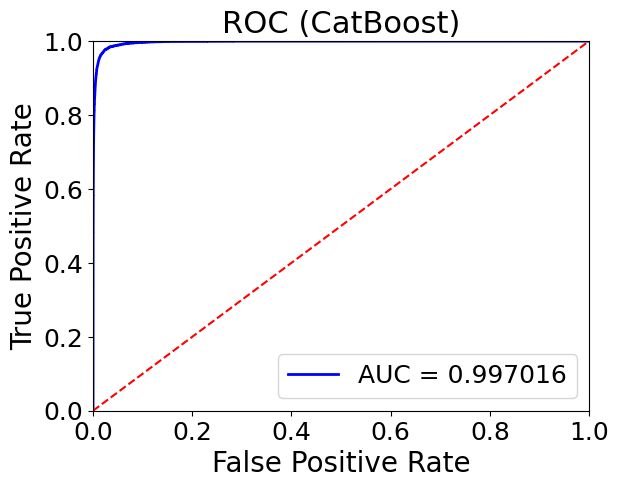

In [22]:
probs = model.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)

plt.title('ROC (CatBoost)', fontsize=22)
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.6f' % roc_auc, linewidth=2)
plt.legend(loc = 'lower right', fontsize=18)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=20)
plt.xlabel('False Positive Rate', fontsize=20)
plt.xticks(fontsize=18) 
plt.yticks(fontsize=18) 
plt.show()

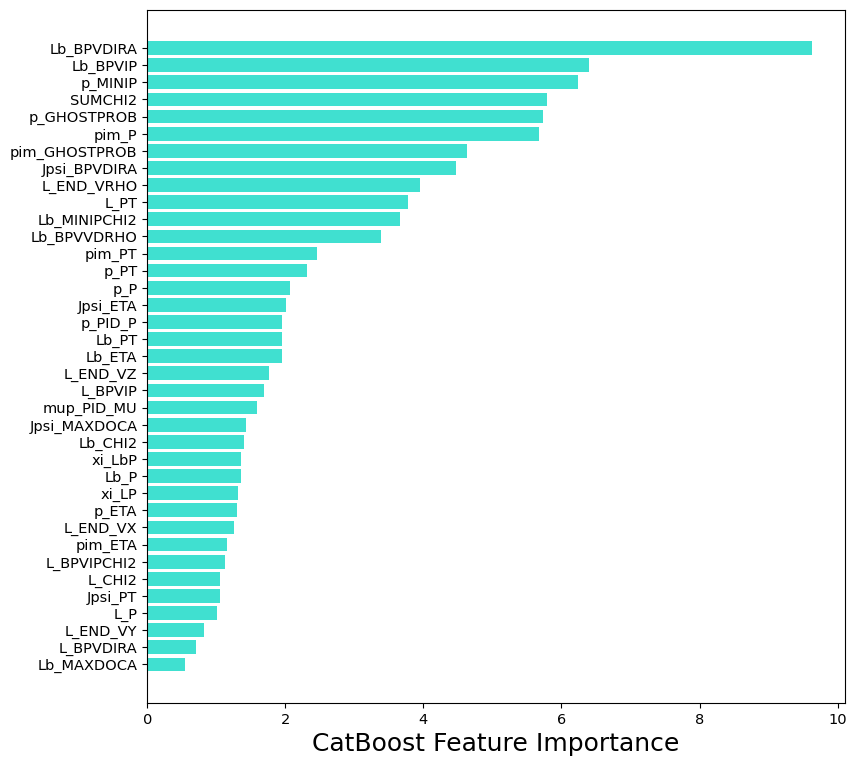

In [23]:
sorted_feature_importance = model.feature_importances_.argsort()
plt.rcParams["figure.figsize"] = (9,9)
plt.barh(X_test.columns[sorted_feature_importance], 
        model.feature_importances_[sorted_feature_importance], 
        color='turquoise')
plt.xlabel("CatBoost Feature Importance", fontsize=18)  # Ajusta el tamaño de fuente de las etiquetas en el eje y
plt.xticks(fontsize=10.5)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=10.5);  # Ajusta el tamaño de fuente de las etiquetas en el eje y

Hasta aquí he reproducido el trabajo de Javier.

Ahora voy a utilizar un conjunto balancedado.

1. Creo el conjunto con datos de señal y de fondo.
1. Muestreo el conjunto de fondo para reducir el número de muestras al mismo valor que el conjuto de datos de señal.
1. Concateno los dos conjuntos.
1. Barajo el conjunto.

In [24]:
signal = new_training[new_training.SIGNAL]
background = new_training[new_training.SIGNAL == False]
number_signal_samples = len(signal)
background_sampled = background.sample(number_signal_samples, random_state=70)
print("Número de muestras en el conjunto de señal:   ", len(signal))
print("Número de muestras en el cojunto de fondo:    ", len(background_sampled))
signal_and_background = pd.concat([signal, background_sampled])
signal_and_background = signal_and_background.sample(frac=1, random_state=69).reset_index(drop=True)
print("Número de muestras en el conjunto balanceado: ", len(signal_and_background))
# signal_and_background

Número de muestras en el conjunto de señal:    28196
Número de muestras en el cojunto de fondo:     28196
Número de muestras en el conjunto balanceado:  56392


Separo en conjunto de entrenamiento y de prueba.

In [25]:
y = signal_and_background.SIGNAL
X = signal_and_background.drop(columns=to_drop)
X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced = train_test_split(X, y, random_state=69)

Defino los parámetros para construir el árbol.

In [26]:
model_params_balanced = {
    'iterations': 1000, 
    'loss_function': 'Logloss',
    'train_dir': 'crossentropy',
    'allow_writing_files': False,
    'od_type': 'IncToDec'
}

In [27]:
train_dataset_balanced = Pool(X_train_balanced, y_train_balanced, feature_names=list(X_train.columns))
test_dataset_balanced = Pool(X_test_balanced, y_test_balanced, feature_names=list(X_test.columns))

Construyo y entreno el árbol.

In [28]:
model_balanced = CatBoostClassifier(**model_params_balanced, 
                                    custom_metric=['Logloss', 'AUC:hints=skip_train~false',
                                                   'Accuracy'])
model_balanced.fit(train_dataset_balanced, verbose=100, plot=False)

Learning rate set to 0.050975
0:	learn: 0.6032755	total: 8.39ms	remaining: 8.38s
100:	learn: 0.0869613	total: 777ms	remaining: 6.92s
200:	learn: 0.0718461	total: 1.53s	remaining: 6.08s
300:	learn: 0.0635011	total: 2.3s	remaining: 5.33s
400:	learn: 0.0568949	total: 3.06s	remaining: 4.58s
500:	learn: 0.0515791	total: 3.8s	remaining: 3.79s
600:	learn: 0.0470521	total: 4.54s	remaining: 3.01s
700:	learn: 0.0434091	total: 5.28s	remaining: 2.25s
800:	learn: 0.0400280	total: 6.04s	remaining: 1.5s
900:	learn: 0.0367939	total: 6.78s	remaining: 745ms
999:	learn: 0.0340383	total: 7.51s	remaining: 0us


Voy a ver cuál es la matriz de confusión para los datos de prueba.

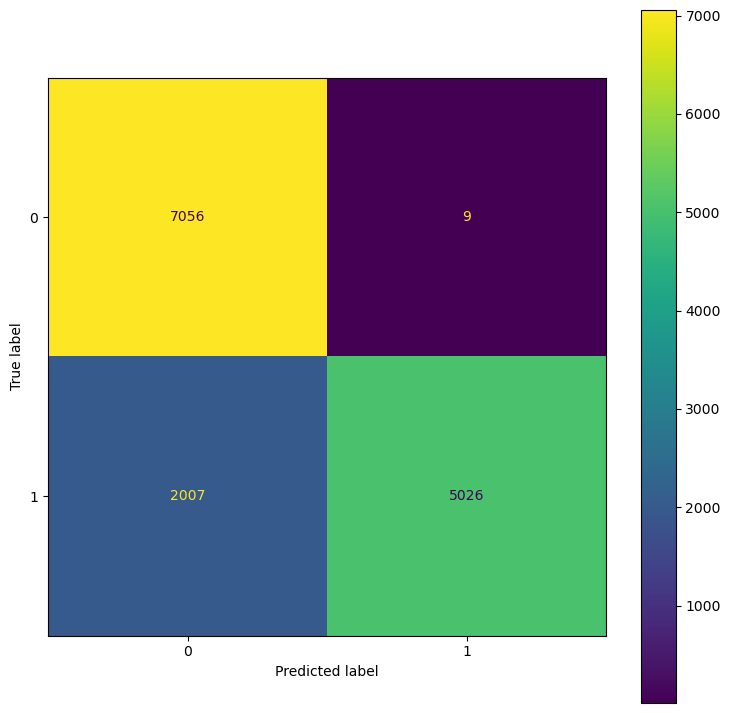

In [29]:
y_pred = [x > 0.99 for x in model_balanced.predict_proba(X_test_balanced)[:,1]]
ConfusionMatrixDisplay(confusion_matrix(y_test_balanced, y_pred)).plot()

Una vez que tengo creado el árbol, a partir de los datos de Montecarlo, lo utilizo para clasificar los eventos de los experimentos como pertenecientes a señal o a fondo.

In [30]:
maxima_probabilidad = 0.99
filtro = model.predict_proba(data24_selected)[:,1] >= maxima_probabilidad
data24_signal = data24_selected[filtro]
data24_background = data24_selected[filtro]
print(data24_signal.shape)

(1284, 40)


Muestros el histograma de los datos parala masa de Lb: todos los datos del experimento, aquellos que Catboost ha calificado como señal, y lo que ha clasificado como fondo.

Candidatos totales:  1754865
Candidatos positivos (clasificados con Catboost):  1284
Masa de Lb con todos los datos:                         5661.081585081587
Masa de Lb sólo con los datos clasificados como señal:  5519.822480103683
Desviación estandar:  292.5641714589768
La masa que aparece en la wikipedia es:                 5619.6


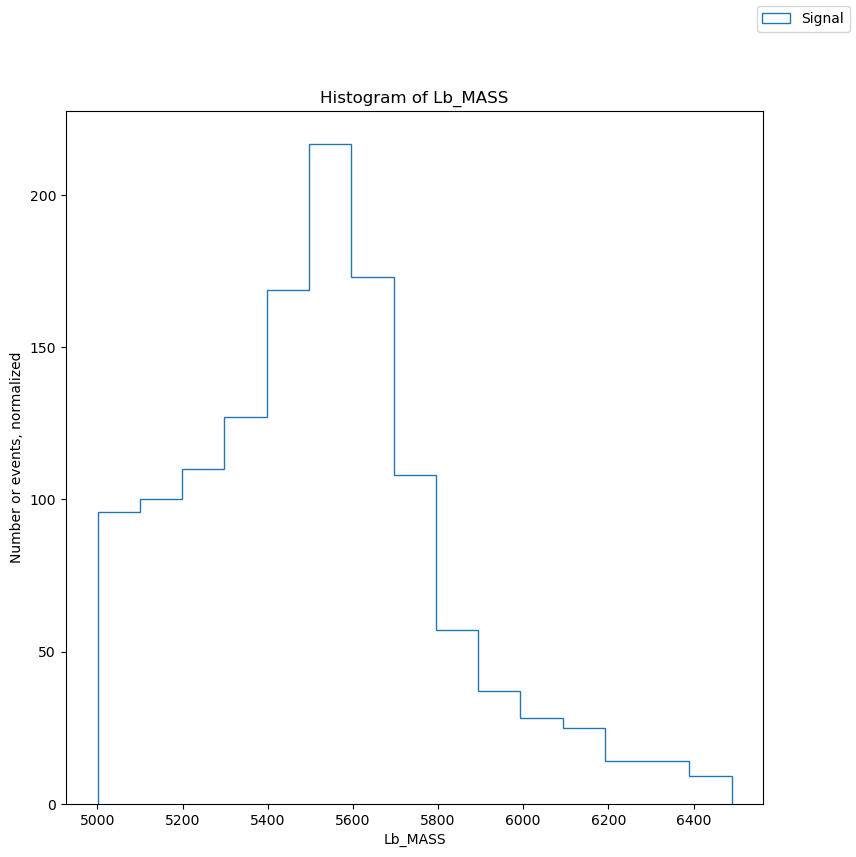

In [31]:
bins = 15
caracteristica = 'Lb_MASS'
density = False
# plt.hist(data24_selected[caracteristica], bins=bins, density=True, histtype='step', label='All data');
plt.hist(data24_signal[caracteristica], bins=bins, density=density, histtype='step', label='Signal');
# plt.hist(data24_background[caracteristica], bins=bins, density=True, histtype='step', label='Background')
# plt.hist(data24_selected[caracteristica], bins=bins, histtype='step', label='All data');
# plt.hist(data24_signal[caracteristica], bins=bins, histtype='step', label='Signal');
# plt.hist(data24_background[caracteristica], bins=bins, histtype='step', label='Background')
plt.xlabel(caracteristica)
plt.ylabel('Number or events, normalized')
plt.title('Histogram of '+ caracteristica)
plt.figlegend()
print("Candidatos totales: ", data24_selected.shape[0])
print("Candidatos positivos (clasificados con Catboost): ", data24_signal.shape[0])
print('Masa de Lb con todos los datos:                        ', np.mean(data24_selected.Lb_MASS))
print('Masa de Lb sólo con los datos clasificados como señal: ', np.mean(data24_signal.Lb_MASS))
print('Desviación estandar: ', np.std(data24_signal.Lb_MASS))
print('La masa que aparece en la wikipedia es:                ', 5619.60)

# plt.hist(mc_signal['Lb_MASS'], bins=bins, density=density, histtype='step', label='All data');

Muestro la gráfica ROC.

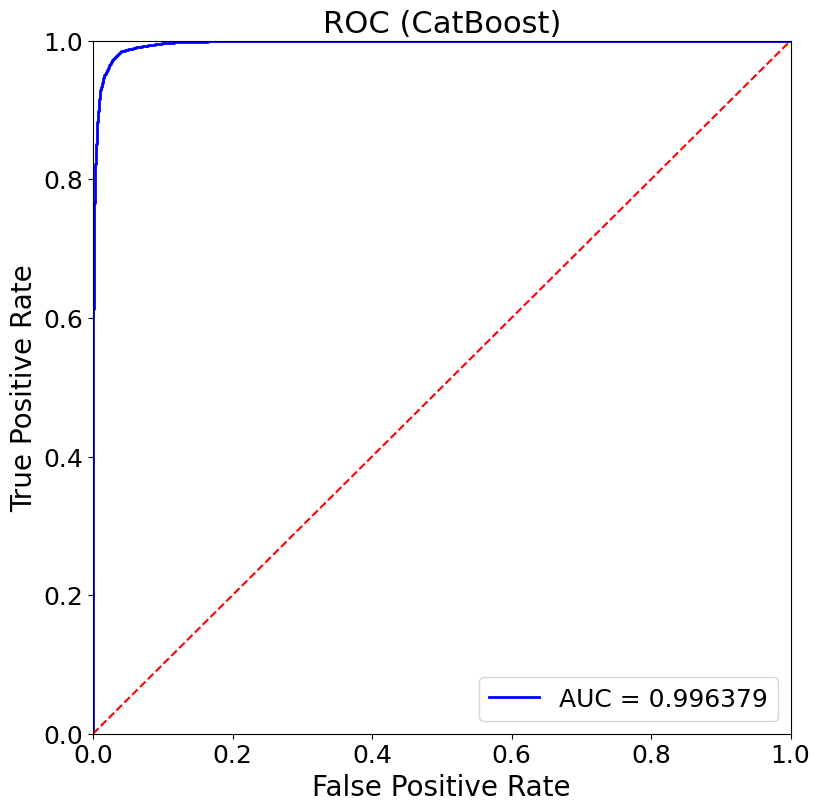

In [32]:
probs = model_balanced.predict_proba(X_test_balanced)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test_balanced, preds)
roc_auc = metrics.auc(fpr, tpr)

plt.title('ROC (CatBoost)', fontsize=22)
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.6f' % roc_auc, linewidth=2)
plt.legend(loc = 'lower right', fontsize=18)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=20)
plt.xlabel('False Positive Rate', fontsize=20)
plt.xticks(fontsize=18) 
plt.yticks(fontsize=18) 
plt.show()

Muestro la característicsa que más influyen en la clasificación de una muestra.

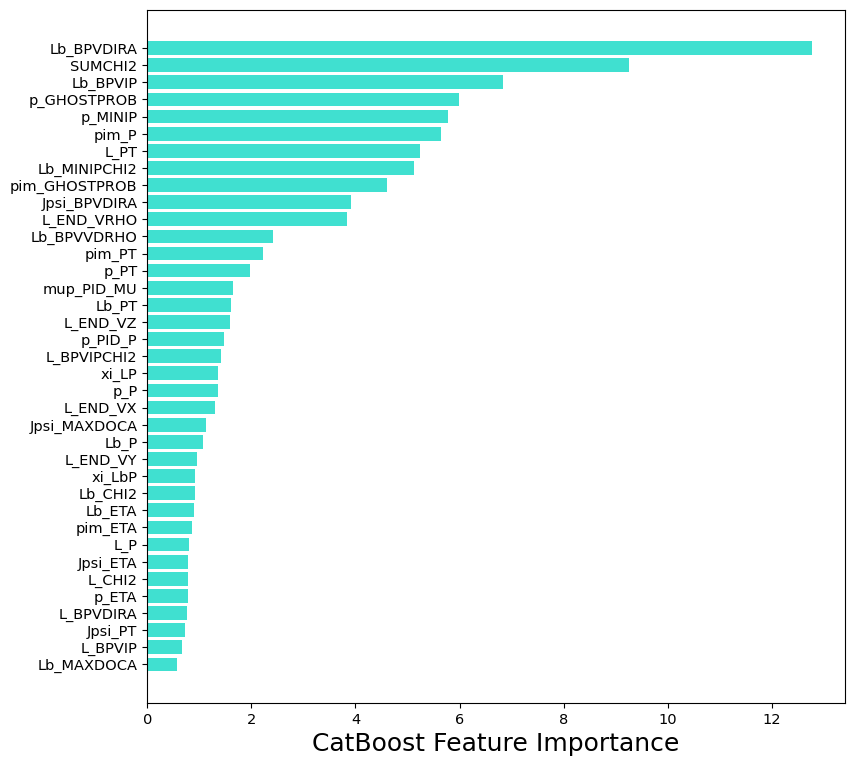

In [33]:
sorted_feature_importance = model_balanced.feature_importances_.argsort()
plt.rcParams["figure.figsize"] = (9,9)
plt.barh(X_test.columns[sorted_feature_importance], 
        model_balanced.feature_importances_[sorted_feature_importance], 
        color='turquoise')
plt.xlabel("CatBoost Feature Importance", fontsize=18)  # Ajusta el tamaño de fuente de las etiquetas en el eje y
plt.xticks(fontsize=10.5)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=10.5);  # Ajusta el tamaño de fuente de las etiquetas en el eje y

A partir de aquí un poco de juego.

In [34]:
# # plt.hist(background_sampled.Lb_BPVDIRA, bins=1000, label="Background")
# plt.hist(signal.Lb_BPVDIRA, bins=100, label="Signal")
# # plt.xlim(0.8,1)
# plt.figlegend();

In [35]:
# plt.scatter(np.sort(signal.Lb_BPVDIRA), np.sort(background_sampled.Lb_BPVDIRA));

In [36]:
print(np.min(signal.Lb_BPVDIRA))
print(np.min(background_sampled.Lb_BPVDIRA))

0.98526096
-0.9929803


In [37]:
# plt.plot(np.sort(signal.Lb_BPVDIRA))
# plt.plot(np.sort(background_sampled.Lb_BPVDIRA));

In [38]:
# plt.hist(signal.SUMCHI2, bins=100)
# plt.hist(background_sampled.SUMCHI2, bins=100)
# ;

In [39]:
# # plt.scatter(signal.Lb_BPVDIRA, signal.SUMCHI2)
# # plt.scatter(background_sampled.Lb_BPVDIRA, background_sampled.SUMCHI2)
# plt.scatter(signal.Lb_BPVDIRA, signal.Lb_BPVIP)
# # plt.scatter(background_sampled.Lb_BPVDIRA, background_sampled.Lb_BPVIP);


In [40]:
signal_and_background

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,SUMCHI2,Cos_xi_LbP,Cos_xi_LP,xi_LbP,xi_LP,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,SIGNAL,CLASS
0,212.449905,294.848907,0.999973,42.768250,5.411863,0.995884,0.195917,0.181653,30.468357,113082.351562,...,13.303243,0.999427,0.999836,0.033845,0.018136,NaN,NaN,5316.512207,False,NaN
1,3880.825439,268.014343,1.000000,1.061152,0.016864,0.999990,0.032766,0.445736,2.380782,114338.859375,...,1.333839,0.999984,0.999854,0.017087,0.005642,0.0,6187.6492,5539.912109,True,0.0
2,2646.174072,276.093750,0.999980,37.055672,13.424700,0.999558,0.013408,0.004700,27.339691,52773.308594,...,22.338723,0.996487,0.999638,0.083851,0.026921,NaN,NaN,5939.362793,False,NaN
3,957.219727,96.028412,0.999939,37.793121,16.683010,0.996069,0.093707,0.086137,38.129185,77630.882812,...,21.406030,0.999885,0.999814,0.015184,0.019277,NaN,NaN,5731.955566,False,NaN
4,1673.955811,600.278931,0.999999,10.387090,2.183446,0.999939,0.035447,0.240470,8.627779,61592.769531,...,5.561988,0.999993,0.999750,0.022358,0.003845,0.0,6656.2319,5065.281250,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56387,3269.813232,299.198975,0.999999,6.902085,1.926531,0.999999,0.008440,0.291472,6.537942,109390.695312,...,2.328246,0.999973,0.999547,0.030111,0.007373,0.0,6291.5646,5573.644043,True,0.0
56388,3323.222412,199.302887,0.999944,34.766018,12.060234,0.999983,0.004336,0.013342,33.901203,103169.210938,...,23.961993,0.996755,0.999845,0.080582,0.017629,NaN,NaN,6072.685547,False,NaN
56389,8753.200195,1037.836426,1.000000,4.818660,0.920030,0.999997,0.048044,3.479021,4.805304,87649.101562,...,3.393697,0.999994,0.999642,0.026741,0.003383,0.0,6647.5248,5419.000977,True,0.0
56390,2813.272949,160.401138,1.000000,1.149706,0.026806,0.999998,0.039909,0.986630,4.383309,133644.906250,...,0.684340,0.999933,0.999666,0.025857,0.011534,0.0,4541.5834,5722.637695,True,0.0


Se acabó el juego anterior.

Para no tener que copiar mucho código, sigo aquí viendo qué pasa con PCA.

In [41]:
def set_clazz(x):
    if x:
        return "GREEN"
    else:
        return "RED"

Creo y entreno el PCA. Hay que escalar los datos para que los más **dispersos** no tengan más pesos en el análisis.

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data_without_nan = signal_and_background.drop(columns=['Lb_BKGCAT', 'p_TRUEORIGIN_VZ', 'CLASS'])
data_without_nan = data_without_nan.dropna()
clazz = [set_clazz(x) for x in data_without_nan.SIGNAL] 
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_without_nan)
pca = PCA(n_components=0.9)
data_pca = pca.fit_transform(data_scaled)
print(data_pca.shape)
print(signal_and_background.shape)
# signal_and_background.CLASS = clazz
# signal_and_background
# data_without_nan
print(data_without_nan[data_without_nan.SIGNAL].shape)
print(data_without_nan[data_without_nan.SIGNAL == False].shape)

(56269, 22)
(56392, 44)
(28080, 41)
(28189, 41)


In [43]:
explained_variance = pca.explained_variance_ratio_
cum_explained_variance = [sum(explained_variance[0:i+1]) for i in range(len(explained_variance))]
x_range = range(1,len(explained_variance)+1)

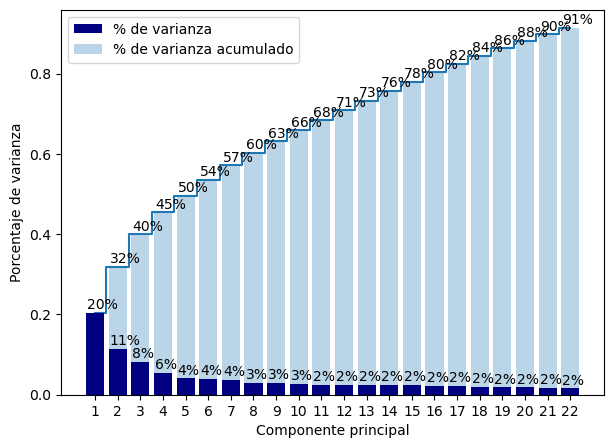

In [44]:
fig, ax = plt.subplots(figsize = (7, 5))
ax.bar(x = x_range, height = explained_variance, zorder = 20,
       color = "navy", label = "% de varianza")
ax.bar(x = x_range, height = cum_explained_variance, alpha = 0.3,
       label = "% de varianza acumulado")
ax.step(x = x_range, y = cum_explained_variance, where = "mid")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Porcentaje de varianza")
for i, v in enumerate(explained_variance):
    ax.text(x = i + 0.65, y = v + 0.01, s = str(round(v * 100)) + "%")
for i, v in enumerate(cum_explained_variance[1:], start = 1):
    ax.text(x = i + 0.65, y = v + 0.01, s = str(round(v * 100)) + "%")
ax.set_xticks(x_range, labels = x_range)
ax.legend()
plt.show()

Ahora voy a ver cómo de bien se separan los datos si sólo tomo las dos primeras variables después de PCA.

Voy a ver si con las dos primeras variables que encuentra PCA es posible separar los datos de señal y de fondo, utiliznado una regresión logística.

In [45]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.inspection import DecisionBoundaryDisplay

# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(data_without_nan)
# X_train, X_test, y_train, y_test = train_test_split(X_pca, clazz)

# logistic = LogisticRegression()
# logistic.fit(X_train, y_train)

# class_names = ["Class " + str(n) for n in y.unique()]

# DecisionBoundaryDisplay.from_estimator(
#     logistic,
#     X_pca,
#     cmap=plt.cm.Paired,
#     ax=ax,
#     response_method="predict",
#     plot_method="pcolormesh",
#     shading="auto",
#     xlabel="Uno",
#     ylabel="Dos",
#     eps=0.5,
# ).plot()

# plt.scatter(X_train[:,0], X_train[:,1], c = y_train);

No parece que sea posible la separación utilizando tan sólo las dos primeras variables que ha encontrado PCA.

Voy a probara clasificar con un MLP.

In [46]:
new_training

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,SUMCHI2,Cos_xi_LbP,Cos_xi_LP,xi_LbP,xi_LP,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,SIGNAL,CLASS
0,3.193901,106.470528,0.999982,20.017588,1.279168,0.999426,0.017131,0.022258,15.024256,1.723121e+05,...,2.097253,0.999658,0.999858,0.026152,0.016869,NaN,NaN,5645.727539,False,NaN
1,3.849078,410.608185,0.999996,19.165550,13.589819,0.999425,0.059135,0.073100,17.049515,5.642727e+04,...,48.184564,0.997900,0.999382,0.064826,0.035155,NaN,NaN,5031.431641,False,NaN
2,4.025047,403.012360,0.999935,44.367485,15.275529,0.992653,0.017111,0.016130,42.076160,6.746895e+04,...,101.922631,0.999000,0.999814,0.044729,0.019267,NaN,NaN,5795.810547,False,NaN
3,4.422329,135.734070,0.999994,23.802071,13.575705,0.995400,0.022364,0.019789,14.871126,1.029982e+05,...,15.007227,0.999997,0.999999,0.002441,0.001337,NaN,NaN,6367.910156,False,NaN
4,4.516160,111.526054,0.999954,35.079712,17.672701,0.999668,0.010694,0.013312,30.626474,7.897278e+04,...,20.355468,0.999243,0.999052,0.038921,0.043552,NaN,NaN,5575.120117,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1783056,54554.156250,485.722290,0.999992,23.871187,9.358157,1.000000,0.008717,1.576908,16.334398,7.674344e+05,...,17.652151,0.999972,0.999956,0.007485,0.009361,NaN,NaN,5555.402832,False,NaN
1783057,56965.722656,271.750549,0.999933,34.971157,6.146852,0.999971,0.044792,0.599378,24.410915,6.463271e+05,...,13.757448,0.999827,0.999684,0.018619,0.025151,NaN,NaN,5086.947754,False,NaN
1783058,60187.128906,140.641922,0.999588,94.522896,28.995571,0.999967,0.066358,0.364922,5.076037,1.685770e+06,...,41.196251,0.999943,0.999742,0.010681,0.022720,NaN,NaN,5821.086426,False,NaN
1783059,60188.066406,518.161621,0.999994,15.621946,1.327115,1.000000,0.027786,8.076616,16.794943,5.538830e+05,...,3.349826,0.999930,0.999934,0.011855,0.011498,NaN,NaN,5818.788574,False,NaN


In [47]:
27//2

13

In [49]:
import joblib
def cambiatruefalse(x):
    if x:
        return 1
    else:
        return 0

mlp_data = data_without_nan.copy()

X = mlp_data.drop(columns=['SIGNAL'])
scaler = StandardScaler()
X = scaler.fit_transform(X)


y = [cambiatruefalse(x) for x in mlp_data.SIGNAL]
# y = mlp_data.SIGNAL

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=69)

neuronas = X_train.shape[1]


mlp = MLPClassifier(
    hidden_layer_sizes=(neuronas, neuronas//2, neuronas//4),
    learning_rate_init=0.001,
    solver = 'lbfgs',
    max_iter = 1000,
    random_state = 69
)

mlp.fit(X_train, y_train);

# Guardar el modelo entrenado
joblib.dump(mlp, 'neural_network_full_range.pkl')

['neural_network_full_range.pkl']

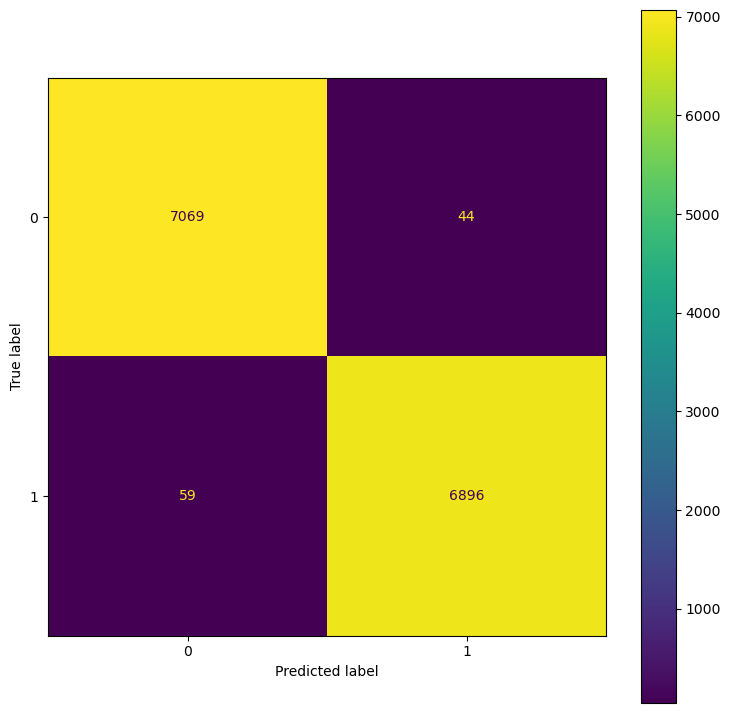

In [50]:
y_pred = mlp.predict_proba(X_test)[:,1] >= 0.99

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

Candidatos totales:  1754575
Candidatos positivos (clasificados con MLP):  329253
Masa de Lb con todos los datos:                         5661.080012876493
Masa de Lb sólo con los datos clasificados como señal:  5610.860713370788
Desviación estandar de la media de la masa de Lb     : 381.3602086352144
La masa que aparece en la wikipedia es:                 5619.6


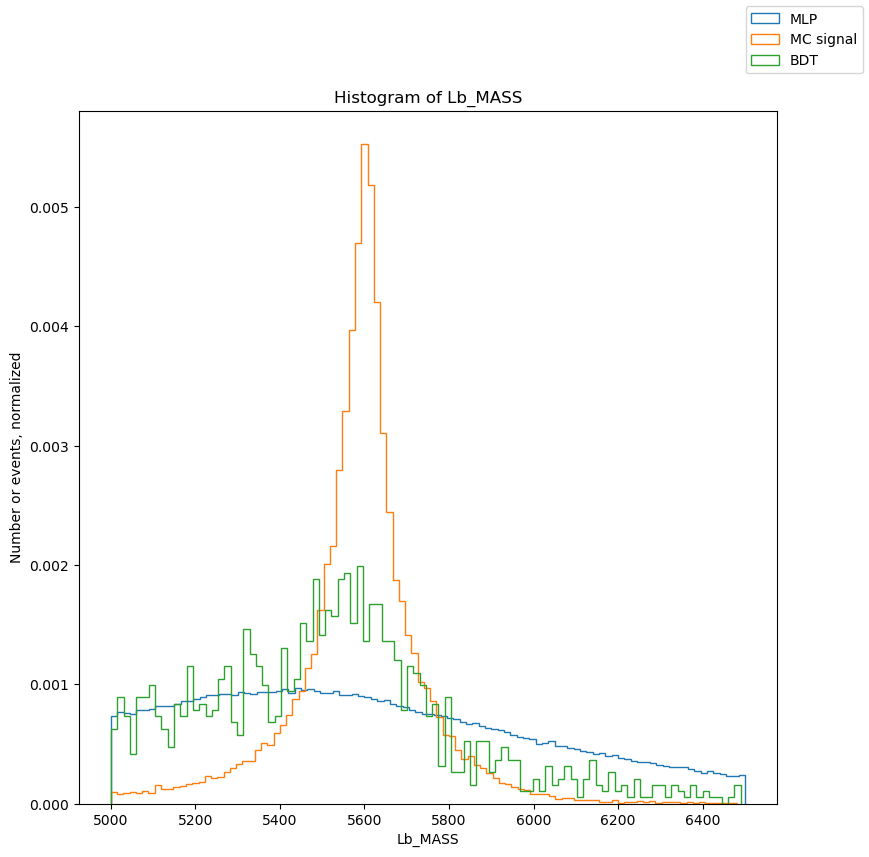

In [51]:
# 
data24_selected_nan = data24_selected.dropna()

scaler = StandardScaler()
data24_selected_nan_scaled = scaler.fit_transform(data24_selected_nan)

maxima_probabilidad = 0.9999999999999999
# y_pred = mlp.predict(data24_selected_nan_scaled)
y_pred = mlp.predict_proba(data24_selected_nan_scaled)[:,1] > maxima_probabilidad

density = True
data24_signal_nan = data24_selected_nan[y_pred]
data24_background_nan = data24_selected_nan[y_pred == False]

bins =100
caracteristica = 'Lb_MASS'
# plt.hist(data24_selected_nan[caracteristica], bins=bins, density=True, histtype='step', label='All data');
# plt.hist(data24_signal_nan[caracteristica], bins=bins, density=True, histtype='step', label='MLP');
# plt.hist(data24_background_nan[caracteristica], bins=bins, density=True, histtype='step', label='Background')
# plt.hist(data24_selected_nan[caracteristica], bins=bins, histtype='step', label='All data');
plt.hist(data24_signal_nan[caracteristica], bins=bins, histtype='step', label='MLP', density= density);
# plt.hist(data24_background_nan[caracteristica], bins=bins, histtype='step', label='Background')
plt.xlabel(caracteristica)
plt.ylabel('Number or events, normalized')
plt.title('Histogram of '+ caracteristica)
print("Candidatos totales: ", data24_selected_nan.shape[0])
print("Candidatos positivos (clasificados con MLP): ", data24_signal_nan.shape[0])
print('Masa de Lb con todos los datos:                        ', np.mean(data24_selected_nan.Lb_MASS))
print('Masa de Lb sólo con los datos clasificados como señal: ', np.mean(data24_signal_nan.Lb_MASS))
print('Desviación estandar de la media de la masa de Lb     :', np.std(data24_signal_nan.Lb_MASS))
print('La masa que aparece en la wikipedia es:                ', 5619.60)

plt.hist(mc_signal['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC signal');
plt.hist(data24_signal[caracteristica], bins=bins, density=density, histtype='step', label='BDT');
plt.figlegend()

Candidatos totales:  1754575
Candidatos positivos (clasificados con MLP):  329253
Masa de Lb con todos los datos:                         5661.080012876493
Masa de Lb sólo con los datos clasificados como señal:  5610.860713370788
Desviación estandar de la media de la masa de Lb     : 381.3602086352144
La masa que aparece en la wikipedia es:                 5619.6


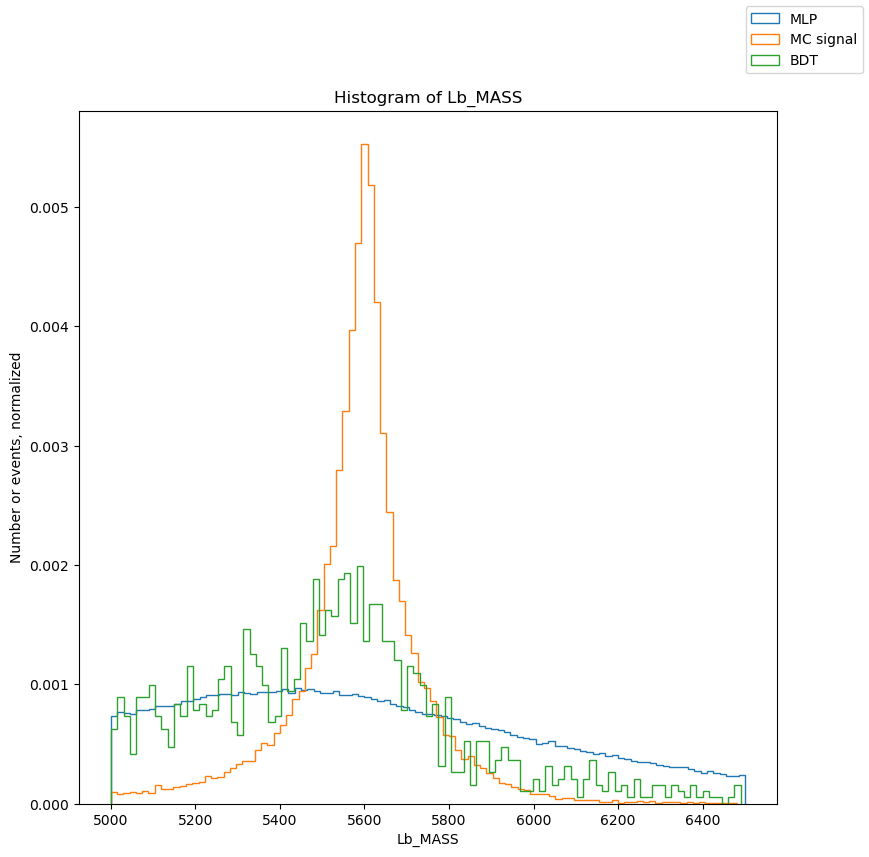

In [52]:
# 
data24_selected_nan = data24_selected.dropna()

scaler = StandardScaler()
data24_selected_nan_scaled = scaler.fit_transform(data24_selected_nan)

maxima_probabilidad = 0.9999999999999999
# y_pred = mlp.predict(data24_selected_nan_scaled)
y_pred = mlp.predict_proba(data24_selected_nan_scaled)[:,1] > maxima_probabilidad

density = True
data24_signal_nan = data24_selected_nan[y_pred]
data24_background_nan = data24_selected_nan[y_pred == False]

bins =100
caracteristica = 'Lb_MASS'
# plt.hist(data24_selected_nan[caracteristica], bins=bins, density=True, histtype='step', label='All data');
# plt.hist(data24_signal_nan[caracteristica], bins=bins, density=True, histtype='step', label='MLP');
# plt.hist(data24_background_nan[caracteristica], bins=bins, density=True, histtype='step', label='Background')
# plt.hist(data24_selected_nan[caracteristica], bins=bins, histtype='step', label='All data');
plt.hist(data24_signal_nan[caracteristica], bins=bins, histtype='step', label='MLP', density= density);
# plt.hist(data24_background_nan[caracteristica], bins=bins, histtype='step', label='Background')
plt.xlabel(caracteristica)
plt.ylabel('Number or events, normalized')
plt.title('Histogram of '+ caracteristica)
print("Candidatos totales: ", data24_selected_nan.shape[0])
print("Candidatos positivos (clasificados con MLP): ", data24_signal_nan.shape[0])
print('Masa de Lb con todos los datos:                        ', np.mean(data24_selected_nan.Lb_MASS))
print('Masa de Lb sólo con los datos clasificados como señal: ', np.mean(data24_signal_nan.Lb_MASS))
print('Desviación estandar de la media de la masa de Lb     :', np.std(data24_signal_nan.Lb_MASS))
print('La masa que aparece en la wikipedia es:                ', 5619.60)

plt.hist(mc_signal['Lb_MASS'], bins=bins, density=density, histtype='step', label='MC signal');
plt.hist(data24_signal[caracteristica], bins=bins, density=density, histtype='step', label='BDT');
plt.figlegend()

A partir de aqui codigo nuevo y modificado 

In [53]:

from sklearn.preprocessing import StandardScaler

# Suponiendo que data24_selected ya está definido
data24_selected_nan = data24_selected.dropna()

scaler = StandardScaler()
data24_selected_nan_scaled = scaler.fit_transform(data24_selected_nan)

maxima_probabilidad = 0.9999999999999999

# Predecir probabilidades en el nuevo conjunto de datos
y_pred = mlp.predict_proba(data24_selected_nan_scaled)[:, 1]

# Filtrar los datos que cumplan con la condición
high_confidence_indices = y_pred > maxima_probabilidad
high_confidence_data = data24_selected_nan[high_confidence_indices]

# Guardar los datos en un archivo CSV
high_confidence_data.to_csv('Neural_network_data.csv', index=False)


In [54]:

# Cargar los datos desde el archivo CSV
neural_data = pd.read_csv('Neural_network_data.csv')

# Ahora puedes trabajar con high_confidence_data
maxima_probabilidad = 0.95
filtro = model.predict_proba(neural_data)[:,1] >= maxima_probabilidad
neural_data_signal = neural_data[filtro]
neural_data_bkg = neural_data[filtro]
print(neural_data.shape)

(329253, 40)


Esto es el resultado de aplicar la BDT después de la neural network 

Candidatos totales:  1754865
Candidatos positivos (clasificados con Catboost):  1284
Masa de Lb con todos los datos:                         5661.081585081587
Masa de Lb sólo con los datos clasificados como señal:  5519.822480103683
Desviación estandar:  292.5641714589768
La masa que aparece en la wikipedia es:                 5619.6


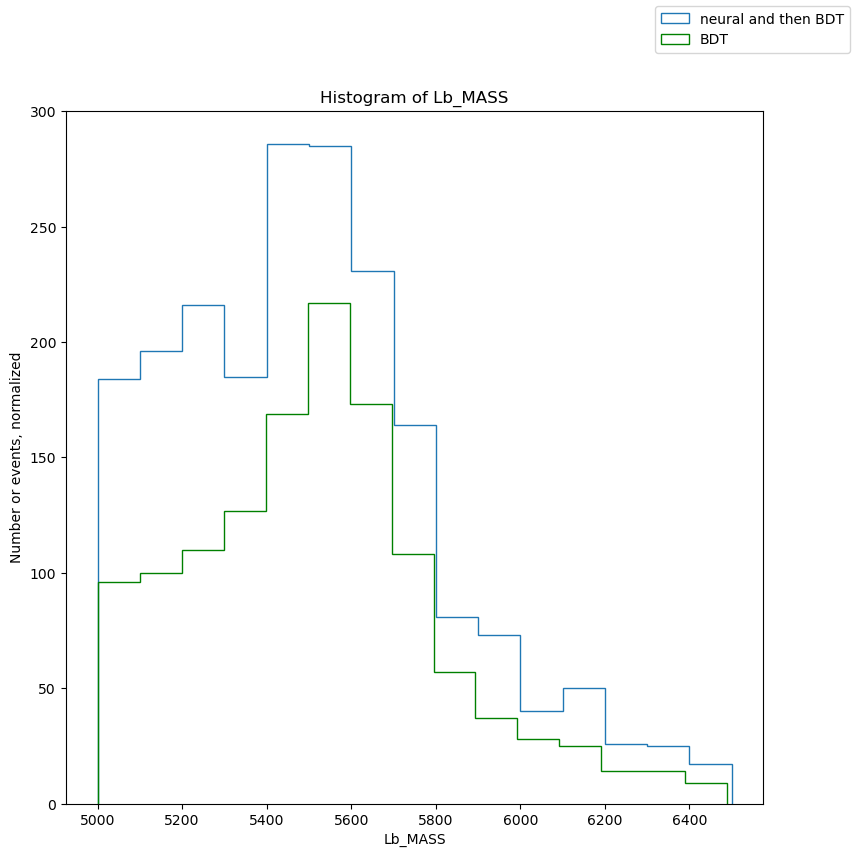

In [55]:
bins = 15
caracteristica = 'Lb_MASS'
density = False
# plt.hist(data24_selected[caracteristica], bins=bins, density=True, histtype='step', label='All data');
plt.hist(neural_data_signal[caracteristica], bins=bins, density=density, histtype='step', label='neural and then BDT');
plt.hist(data24_signal[caracteristica], bins=bins, density=density, histtype='step', label='BDT', color='green');
# plt.hist(data24_background[caracteristica], bins=bins, density=True, histtype='step', label='Background')
# plt.hist(data24_selected[caracteristica], bins=bins, histtype='step', label='All data');
# plt.hist(data24_signal[caracteristica], bins=bins, histtype='step', label='Signal');
# plt.hist(data24_background[caracteristica], bins=bins, histtype='step', label='Background')
plt.xlabel(caracteristica)
plt.ylabel('Number or events, normalized')
plt.title('Histogram of '+ caracteristica)
plt.figlegend()
print("Candidatos totales: ", data24_selected.shape[0])
print("Candidatos positivos (clasificados con Catboost): ", data24_signal.shape[0])
print('Masa de Lb con todos los datos:                        ', np.mean(data24_selected.Lb_MASS))
print('Masa de Lb sólo con los datos clasificados como señal: ', np.mean(data24_signal.Lb_MASS))
print('Desviación estandar: ', np.std(data24_signal.Lb_MASS))
print('La masa que aparece en la wikipedia es:                ', 5619.60)


# plt.hist(mc_signal['Lb_MASS'], bins=bins, density=density, histtype='step', label='All data');

In [56]:
model = CatBoostClassifier().load_model("new_BDT")
prob = model.predict_proba(mc_bkg_selected)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
mc_bkg_selected['prob1'] = signal_MVA_probs

[[9.99534163e-01 4.65836785e-04]
 [1.17816371e-03 9.98821836e-01]
 [9.99051547e-01 9.48453044e-04]
 ...
 [3.52616414e-02 9.64738359e-01]
 [2.42060430e-03 9.97579396e-01]
 [1.81005458e-05 9.99981899e-01]]


In [57]:
mc_bkg_selected.columns

Index(['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'SUMCHI2',
       'Cos_xi_LbP', 'Cos_xi_LP', 'xi_LbP', 'xi_LP', 'Lb_BKGCAT',
       'p_TRUEORIGIN_VZ', 'Lb_MASS', 'prob1'],
      dtype='object')

In [58]:

from sklearn.preprocessing import StandardScaler

# Suponiendo que data24_selected ya está definido
data24_selected_nan = mc_bkg_selected.dropna()

scaler = StandardScaler()
data24_selected_nan_scaled = scaler.fit_transform(data24_selected_nan)

maxima_probabilidad = 0.9999999999999999

# Predecir probabilidades en el nuevo conjunto de datos
y_pred = mlp.predict_proba(data24_selected_nan_scaled)[:, 1]

# Filtrar los datos que cumplan con la condición
high_confidence_indices = y_pred > maxima_probabilidad
high_confidence_data = data24_selected_nan[high_confidence_indices]

# # Guardar los datos en un archivo CSV
# high_confidence_data.to_csv('Neural_network_dat_bkg.csv', index=False)

ValueError: X has 43 features, but MLPClassifier is expecting 40 features as input.